In [13]:
# We create the XOR dataset once using NumPy. This dataset will be shared across all frameworks.
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset (NumPy)
X_np = np.array([[0,0],
                 [0,1],
                 [1,0],
                 [1,1]], dtype=np.float32)

y_np = np.array([[0],
                 [1],
                 [1],
                 [0]], dtype=np.float32)

print("X:\n", X_np)
print("y:\n", y_np)


X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [14]:
def print_xor_table(X, y_true, y_pred_labels, title="XOR Results"):
    print("\n" + title)
    print("-"*40)
    for i in range(len(X)):
        print(f"Input: {X[i]} | Predicted: {int(y_pred_labels[i][0])} | Actual: {int(y_true[i][0])}")


In [17]:
# This plots probability output over a 2D grid → shows learned decision boundary.
def plot_decision_boundary(predict_fn, model_or_params, title="Decision Boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    probs = predict_fn(model_or_params, grid)
    Z = probs.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, levels=50, alpha=0.75)
    plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)

    # plot original XOR points
    plt.scatter(X_np[:,0], X_np[:,1], c=y_np.reshape(-1), s=120, edgecolors="k")

    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()


In [18]:
# Keras Model Training Function
# Keras provides the easiest implementation using Sequential, .compile(), .fit().
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def train_xor_keras(hidden_neurons=4, activation='tanh', lr=0.1, epochs=500):
    model = Sequential([
        Dense(hidden_neurons, input_shape=(2,), activation=activation),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X_np, y_np, epochs=epochs, verbose=0)

    preds = model.predict(X_np, verbose=0)
    pred_labels = (preds > 0.5).astype(int)

    return model, history.history, preds, pred_labels



Keras XOR Results
----------------------------------------
Input: [0. 0.] | Predicted: 0 | Actual: 0
Input: [0. 1.] | Predicted: 1 | Actual: 1
Input: [1. 0.] | Predicted: 1 | Actual: 1
Input: [1. 1.] | Predicted: 0 | Actual: 0
Final Loss: 0.0006081851315684617 | Final Accuracy: 1.0


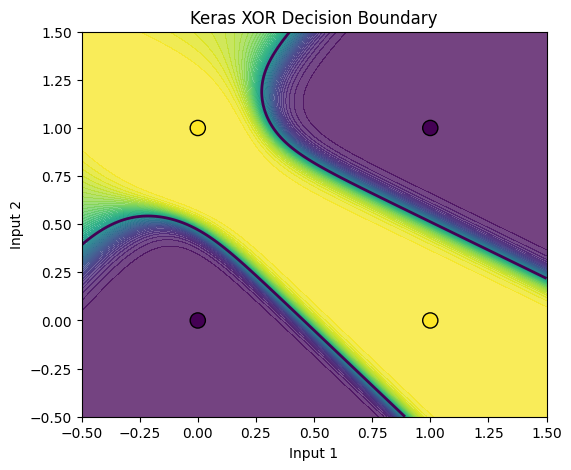

In [28]:
keras_model, keras_hist, keras_preds, keras_labels = train_xor_keras(
    hidden_neurons=4, activation="tanh", lr=0.1, epochs=500
)

print_xor_table(X_np, y_np, keras_labels, title="Keras XOR Results")
print("Final Loss:", keras_hist['loss'][-1], "| Final Accuracy:", keras_hist['accuracy'][-1])


# Decision boundary
def keras_predict_fn(model, Xgrid_np):
    return model.predict(Xgrid_np, verbose=0).reshape(-1)

plot_decision_boundary(keras_predict_fn, keras_model, "Keras XOR Decision Boundary")


In [20]:
# PyTorch Imports + Tensor Conversion
# PyTorch requires explicit dataset tensors.
import torch
import torch.nn as nn
import torch.optim as optim

X_torch = torch.tensor(X_np, dtype=torch.float32)
y_torch = torch.tensor(y_np, dtype=torch.float32)


In [22]:
# Here training is manual:
# forward pass
# loss
# backward
# optimizer step
class XORNet(nn.Module):
    def __init__(self, hidden_neurons=4, activation="tanh"):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_neurons)
        self.fc2 = nn.Linear(hidden_neurons, 1)

        if activation == "tanh":
            self.act = torch.tanh
        elif activation == "relu":
            self.act = torch.relu
        elif activation == "sigmoid":
            self.act = torch.sigmoid
        else:
            raise ValueError("activation must be tanh/relu/sigmoid")

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x


def train_xor_pytorch(hidden_neurons=4, activation="tanh", lr=0.1, epochs=500):
    model = XORNet(hidden_neurons, activation)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    accuracies = []

    for _ in range(epochs):
        optimizer.zero_grad()
        out = model(X_torch)
        loss = criterion(out, y_torch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pred_labels = (out.detach().numpy() > 0.5).astype(int)
        acc = (pred_labels == y_np).mean()
        accuracies.append(acc)

    with torch.no_grad():
        preds = model(X_torch).numpy()
        pred_labels = (preds > 0.5).astype(int)

    hist = {"loss": losses, "accuracy": accuracies}
    return model, hist, preds, pred_labels



PyTorch XOR Results
----------------------------------------
Input: [0. 0.] | Predicted: 0 | Actual: 0
Input: [0. 1.] | Predicted: 1 | Actual: 1
Input: [1. 0.] | Predicted: 1 | Actual: 1
Input: [1. 1.] | Predicted: 0 | Actual: 0
Final Loss: 0.00043029262451454997 | Final Accuracy: 1.0


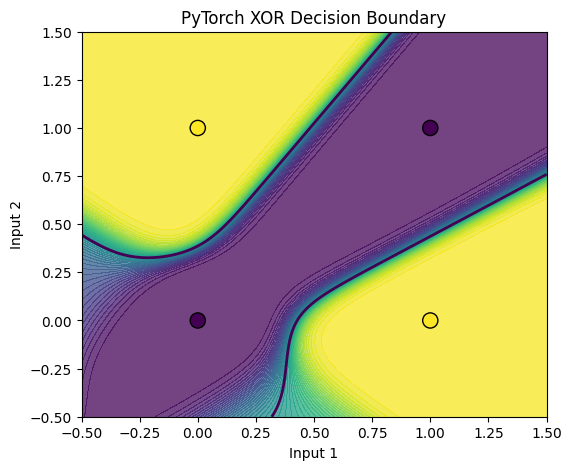

In [26]:
torch_model, torch_hist, torch_preds, torch_labels = train_xor_pytorch(
    hidden_neurons=4, activation="tanh", lr=0.1, epochs=500
)

print_xor_table(X_np, y_np, torch_labels, title="PyTorch XOR Results")
print("Final Loss:", torch_hist['loss'][-1], "| Final Accuracy:", torch_hist['accuracy'][-1])



def pytorch_predict_fn(model, Xgrid_np):
    with torch.no_grad():
        Xgrid_t = torch.tensor(Xgrid_np, dtype=torch.float32)
        return model(Xgrid_t).numpy().reshape(-1)

plot_decision_boundary(pytorch_predict_fn, torch_model, "PyTorch XOR Decision Boundary")


In [24]:
# TensorFlow Low-Level Training Function
# No .fit(), no Dense layers. We manually define: weights, forward pass, gradients, optimizer updates

X_tf = tf.constant(X_np)
y_tf = tf.constant(y_np)

def get_activation_tf(name):
    if name == "tanh": return tf.nn.tanh
    if name == "relu": return tf.nn.relu
    if name == "sigmoid": return tf.nn.sigmoid
    raise ValueError("activation must be tanh/relu/sigmoid")


def train_xor_tf_low(hidden_neurons=4, activation="tanh", lr=0.1, epochs=500):
    act_fn = get_activation_tf(activation)

    # weights
    W1 = tf.Variable(tf.random.normal([2, hidden_neurons]))
    b1 = tf.Variable(tf.zeros([hidden_neurons]))
    W2 = tf.Variable(tf.random.normal([hidden_neurons, 1]))
    b2 = tf.Variable(tf.zeros([1]))

    optimizer = tf.optimizers.Adam(learning_rate=lr)

    losses = []
    accuracies = []

    def forward(X):
        h = act_fn(tf.matmul(X, W1) + b1)
        yhat = tf.nn.sigmoid(tf.matmul(h, W2) + b2)
        return yhat

    for _ in range(epochs):
        with tf.GradientTape() as tape:
            y_pred = forward(X_tf)
            loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_tf, y_pred))

        grads = tape.gradient(loss, [W1, b1, W2, b2])
        optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

        losses.append(float(loss.numpy()))
        pred_labels = (y_pred.numpy() > 0.5).astype(int)
        acc = (pred_labels == y_np).mean()
        accuracies.append(acc)

    params = (W1, b1, W2, b2, activation)
    preds = forward(X_tf).numpy()
    pred_labels = (preds > 0.5).astype(int)

    hist = {"loss": losses, "accuracy": accuracies}
    return params, hist, preds, pred_labels



TensorFlow Low-Level XOR Results
----------------------------------------
Input: [0. 0.] | Predicted: 0 | Actual: 0
Input: [0. 1.] | Predicted: 1 | Actual: 1
Input: [1. 0.] | Predicted: 1 | Actual: 1
Input: [1. 1.] | Predicted: 0 | Actual: 0
Final Loss: 0.0005828312714584172 | Final Accuracy: 1.0


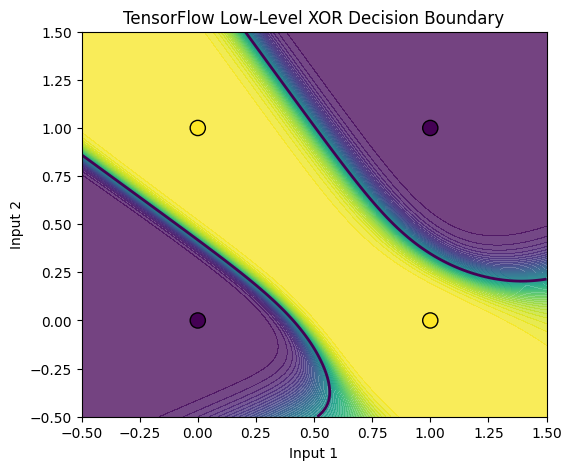

In [27]:
tf_params, tf_hist, tf_preds, tf_labels = train_xor_tf_low(
    hidden_neurons=4, activation="tanh", lr=0.1, epochs=500
)

print_xor_table(X_np, y_np, tf_labels, title="TensorFlow Low-Level XOR Results")
print("Final Loss:", tf_hist['loss'][-1], "| Final Accuracy:", tf_hist['accuracy'][-1])



def tf_low_predict_fn(params, Xgrid_np):
    W1, b1, W2, b2, activation = params
    act_fn = get_activation_tf(activation)

    Xgrid_tf = tf.constant(Xgrid_np, dtype=tf.float32)
    h = act_fn(tf.matmul(Xgrid_tf, W1) + b1)
    yhat = tf.nn.sigmoid(tf.matmul(h, W2) + b2)
    return yhat.numpy().reshape(-1)

plot_decision_boundary(tf_low_predict_fn, tf_params, "TensorFlow Low-Level XOR Decision Boundary")


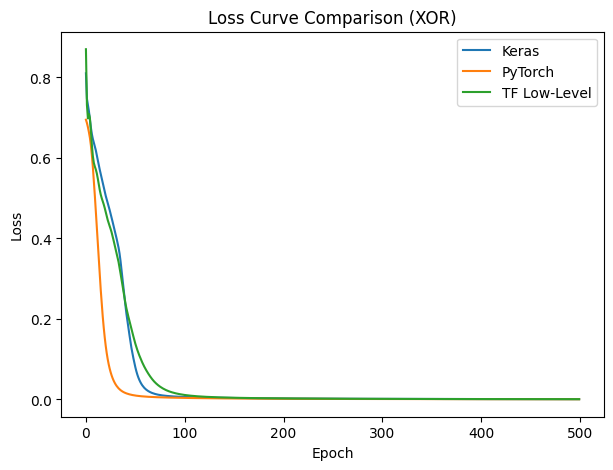

In [29]:
plt.figure(figsize=(7,5))
plt.plot(keras_hist["loss"], label="Keras")
plt.plot(torch_hist["loss"], label="PyTorch")
plt.plot(tf_hist["loss"], label="TF Low-Level")
plt.title("Loss Curve Comparison (XOR)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [31]:
def run_sweep(param_name, values):
    print(f"\n\n========== SWEEP: {param_name} ==========")

    for v in values:
        kwargs = {param_name: v}

        # Keras
        km, kh, _, kl = train_xor_keras(**kwargs)
        # PyTorch
        pm, ph, _, pl = train_xor_pytorch(**kwargs)
        # TF Low
        tp, th, _, tl = train_xor_tf_low(**kwargs)

        print("\n----------------------------------------")
        print(f"{param_name} = {v}")
        print("Keras    :", kl.T, "Final Loss:", round(kh['loss'][-1], 6))
        print("PyTorch  :", pl.T, "Final Loss:", round(ph['loss'][-1], 6))
        print("TF Low   :", tl.T, "Final Loss:", round(th['loss'][-1], 6))


In [32]:
run_sweep("lr", [0.001, 0.01, 0.05, 0.1, 1.0])
run_sweep("activation", ["sigmoid", "relu", "tanh"])
run_sweep("hidden_neurons", [1, 2, 4, 8])
run_sweep("epochs", [50, 100, 500, 2000])




========== SWEEP: lr ==========

----------------------------------------
lr = 0.001
Keras    : [[1 0 1 0]] Final Loss: 0.662174
PyTorch  : [[0 1 1 0]] Final Loss: 0.573836
TF Low   : [[0 1 1 0]] Final Loss: 0.502663

----------------------------------------
lr = 0.01
Keras    : [[0 1 1 0]] Final Loss: 0.013228
PyTorch  : [[0 1 1 0]] Final Loss: 0.016052
TF Low   : [[0 1 1 0]] Final Loss: 0.032331

----------------------------------------
lr = 0.05
Keras    : [[0 1 1 0]] Final Loss: 0.000395
PyTorch  : [[0 1 1 0]] Final Loss: 0.001524
TF Low   : [[0 1 1 0]] Final Loss: 0.001336

----------------------------------------
lr = 0.1
Keras    : [[0 1 1 0]] Final Loss: 0.000692
PyTorch  : [[0 1 0 1]] Final Loss: 0.346777
TF Low   : [[0 1 1 0]] Final Loss: 0.000549

----------------------------------------
lr = 1.0
Keras    : [[0 1 1 1]] Final Loss: 0.346603
PyTorch  : [[0 1 1 0]] Final Loss: 0.000147
TF Low   : [[0 1 1 0]] Final Loss: 0.000132


========== SWEEP: activation ==========

----

Learning rate strongly affects XOR learning. Moderate values (0.01–0.05) consistently converge across frameworks, while very small (0.001) slows learning and very large (0.1–1.0) introduces instability and dependence on initialization, causing inconsistent predictions in some frameworks.


The tanh activation produced the most consistent convergence across all frameworks due to its symmetric output range (-1,1), which matches XOR geometry. ReLU was unstable and failed in PyTorch and TensorFlow low-level, likely due to dead neurons and asymmetric activations.

XOR cannot be learned using only one hidden neuron, confirming the requirement of at least two hidden neurons for non-linear separability. Increasing neurons to 4 and 8 improves convergence stability and reduces final loss due to increased representational capacity.

The XOR problem converges quickly; even 50 epochs provide correct classification. Increasing epochs reduces BCE loss further by increasing prediction confidence, but beyond 500 epochs improvements are minimal, showing that more epochs cannot fix poor hyperparameter choices.